<h1> Use of the Experiment class </h1>

In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
pi = np.pi
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports

from src.xp_config import ExperimentConfig
from src.experiment import Experiment
from src.bare_param import get_bare_param

<h2> Generate an initial configutation </h1>

The initial configuration is as follows:
- Monochromatic photonic wave packet $(\omega_p, \Delta_k, x_0)$ for both photons
- Atom and cavity length $(\omega_0, \gamma, L)$
- Time evolution $(T, dt)$
- IR and UV cutoffs $(\Lambda_{\rm IR}, \Lambda_{\rm UV})$

In [49]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Frequency window
omega_ref = omega_A - Gamma/2
lbda = 0.7*Gamma
cutoffs = {'ir_cutoff': omega_ref - lbda , 'uv_cutoff': omega_ref + lbda}

#Bare parameters
omega_0, gamma = get_bare_param(omega_A, Gamma, omega_ref, lbda)

#Parameters of the simulation
L = 50

param_cavity = {'omega_0': omega_0, 'gamma': gamma, 'L': L}

param_time_evol = {'T': L/2, 'dt': 0.01}

param_photons = {'omega_p': [omega_A - Gamma/2, omega_A - Gamma/2 ], 
                 'delta_k': [0.05*pi, 0.05*pi],
                 'x_0': [-L/4, -L/4]}

#Sanity checks
print("sig_q_critical = ", 4/L)
print("sig_q = ", param_photons['delta_k'][0])

if param_photons['delta_k'][0] < 4/L:
    print("Warning : wave packet delocalized in space")

sig_q_critical =  0.08
sig_q =  0.15707963267948966


<h2> Run an experiment </h2>

In [50]:
config = ExperimentConfig(param_photons, param_cavity, param_time_evol, cutoffs)
scattering_experiment = Experiment(config)
c_array, b1_array, b2_array = scattering_experiment.propagate_state(progress=True)

#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2499/2499 [00:15<00:00, 165.94it/s]


<h2> Visualize excitation numbers </h2>

Get the observables and generate a time array for the figure

In [51]:
time_array = np.arange(0, param_time_evol['T'], param_time_evol['dt'])   
#Compute observables
An_array, P11n_array, P12n_array, P21n_array, P22n_array = scattering_experiment.compute_observables(progress=True)
#Check eventual messages
messages = scattering_experiment.get_messages()

100%|██████████| 2500/2500 [00:00<00:00, 3094.37it/s]


Numerical checks

In [52]:
print('Anti-bunch proba:', P12n_array[-1] + P21n_array[-1])
print('Ejected in same channels proba', P11n_array[-1] + P22n_array[-1])
print('Conservation : ', P12n_array[-1] + P21n_array[-1] + P11n_array[-1] + P22n_array[-1])

Anti-bunch proba: 0.014274244851937018
Ejected in same channels proba 0.9855839322005002
Conservation :  0.9998581770524373


Figure

Anti HOM probability : 0.014274244851937018


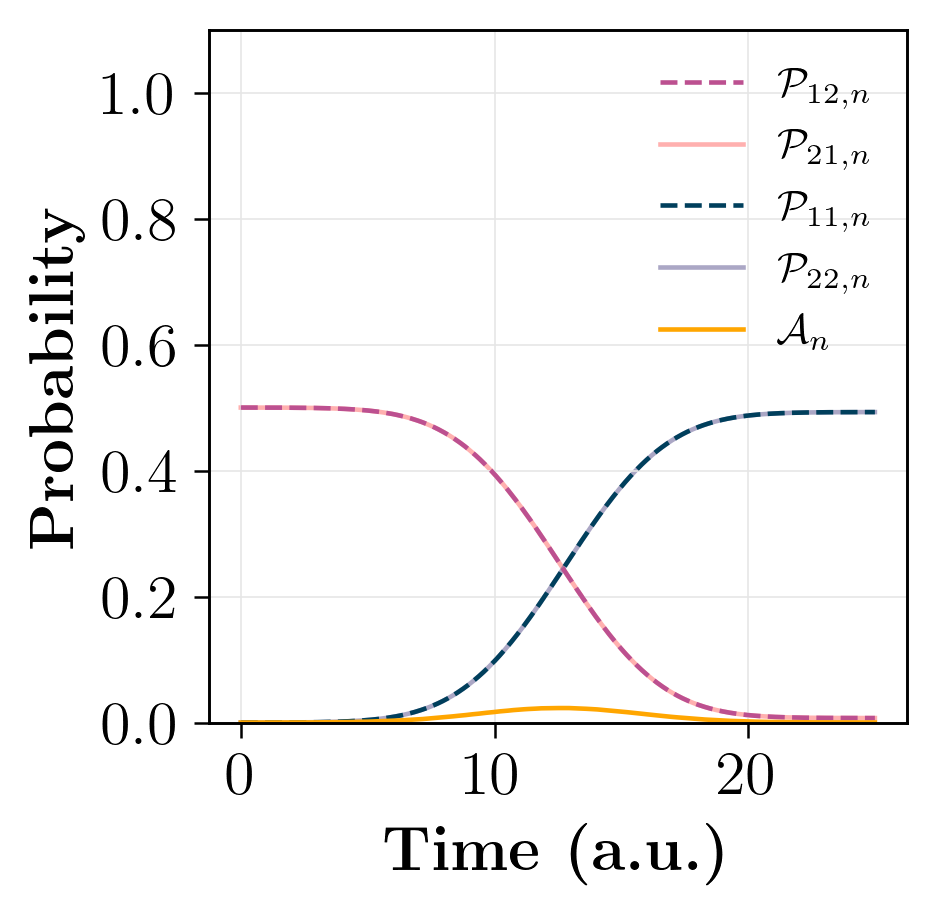

In [53]:
print("Anti HOM probability :", P12n_array[-1] + P21n_array[-1])

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)


color_P11 = '#003f5c'     
color_P22 = '#58508d'     

color_P12 = '#bc5090'     
color_P21 = '#ff6361'     



color_atom = '#ffa600'

# ---- courbes lisses ----

ax.plot(time_array, P12n_array , linestyle='--', color=color_P12, lw=1.1, label=r'$\mathcal{P}_{12, n}$', alpha=1, zorder=2)
ax.plot(time_array, P21n_array , linestyle='-', color=color_P21, lw=1.1, label=r'$\mathcal{P}_{21, n}$', alpha=0.5, zorder=0)

ax.plot(time_array, P11n_array , linestyle='--', color=color_P11, lw=1.1, label=r'$\mathcal{P}_{11, n}$',alpha=1, zorder=2)
ax.plot(time_array, P22n_array , linestyle='-', color=color_P22, lw=1.1, label=r'$\mathcal{P}_{22, n}$', alpha=0.5, zorder=0)

ax.plot(time_array, An_array, '-', color=color_atom, lw=1.1, label=r'$\mathcal{A}_n$')


# Labels, limites et grille
ax.set_xlabel(r'\textbf{Time (a.u.)}', fontsize=10)
ax.set_ylabel(r'\textbf{Probability}', fontsize=10)

ax.set_ylim([0,1.1])


ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="upper right", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

#plt.savefig("../results/fig/single_photon_example_1.25omega0.pdf", bbox_inches="tight")
plt.show()